# Handcrafted Acoustic Features

This notebook extracts handcrafted acoustic features from the FakeMusicCaps pilot dataset.

The goal is to represent each audio clip as a fixed-size numeric feature vector that can later be used for:
- exploratory analysis,
- comparison between music generators,
- baseline classification models.

We use the prepared `pilot_metadata.csv`, which contains 3000 balanced audio samples and predefined train/validation/test splits.

To avoid data leakage and keep experiments comparable, we use the existing splits and do not create new ones in this notebook.

## 1. Load pilot metadata

First, we load the prepared pilot dataset and check its size, class balance, and split distribution.

In [1]:
import pandas as pd

pilot_df = pd.read_csv("../data/interim/pilot_metadata.csv")

pilot_df.head()

,track_id,generator,path,caption,duration,sample_rate,channels,format,subtype,max_amplitude,rms,split
0,-Dtir74TiUM,MusicGen_medium,../data/raw/fakemusiccaps/MusicGen_medium/-Dti...,This is a drum & bass music piece. There is a ...,10.18,16000,1,WAV,FLOAT,0.685177,0.070020,train
1,-FlvaZQOr2I,MusicGen_medium,../data/raw/fakemusiccaps/MusicGen_medium/-Flv...,The song is an instrumental. The song is mediu...,10.18,16000,1,WAV,FLOAT,0.952592,0.172100,validation
2,-IZbvEO9wzU,MusicGen_medium,../data/raw/fakemusiccaps/MusicGen_medium/-IZb...,This is a heavily edited version of a birthday...,10.18,16000,1,WAV,FLOAT,0.383830,0.061743,validation
3,-M-6VinyMiY,MusicGen_medium,../data/raw/fakemusiccaps/MusicGen_medium/-M-6...,The low quality recording features a rock song...,10.18,16000,1,WAV,FLOAT,0.722213,0.068807,train
4,-VclCul6FrI,MusicGen_medium,../data/raw/fakemusiccaps/MusicGen_medium/-Vcl...,The low quality recording features a jazzy org...,10.18,16000,1,WAV,FLOAT,0.752216,0.241172,train


In [11]:
pilot_df.shape

(3000, 12)

In [4]:
pilot_df["generator"].value_counts()

generator
MusicGen_medium      600
audioldm2            600
musicldm             600
mustango             600
stable_audio_open    600
Name: count, dtype: int64

In [5]:
pilot_df["split"].value_counts()

split
train         2100
validation     450
test           450
Name: count, dtype: int64

The pilot dataset contains 3000 audio files, with 600 samples for each generator.  
The predefined split contains 2100 training samples, 450 validation samples, and 450 test samples.

## 2. Inspect available metadata

Before extracting features, we check which information is already available for each audio file.

In [6]:
pilot_df.columns.tolist()

['track_id',
 'generator',
 'path',
 'caption',
 'duration',
 'sample_rate',
 'channels',
 'format',
 'subtype',
 'max_amplitude',
 'rms',
 'split']

In [7]:
pilot_df.head(1).T

,0
track_id,-Dtir74TiUM
generator,MusicGen_medium
path,../data/raw/fakemusiccaps/MusicGen_medium/-Dti...
caption,This is a drum & bass music piece. There is a ...
duration,10.18
sample_rate,16000
channels,1
format,WAV
subtype,FLOAT
max_amplitude,0.685177


The metadata includes the track ID, generator, file path, caption, technical audio properties, and the predefined split.

The `path` column can be used directly to load each audio file.

## 3. Load and preprocess one audio sample

Before processing the full dataset, we test the existing audio loading and preprocessing functions on a single file.

In [8]:
from pathlib import Path
from ai_music_origin.data import load_audio, preprocess_audio

row = pilot_df.iloc[0]

audio_path = Path(row["path"])

print(audio_path)
print(audio_path.exists())

../data/raw/fakemusiccaps/MusicGen_medium/-Dtir74TiUM.wav
True


In [9]:
audio, sr = load_audio(audio_path)

print("Generator:", row["generator"])
print("Track ID:", row["track_id"])
print("Split:", row["split"])
print("Shape:", audio.shape)
print("Sample rate:", sr)
print("Duration:", len(audio) / sr)

Generator: MusicGen_medium
Track ID: -Dtir74TiUM
Split: train
Shape: (162880,)
Sample rate: 16000
Duration: 10.18


In [10]:
audio_processed = preprocess_audio(
    audio,
    sr,
    target_duration=10.0,
    normalize=False,
)

print("Original duration:", len(audio) / sr)
print("Processed duration:", len(audio_processed) / sr)

Original duration: 10.18
Processed duration: 10.0


The sample is successfully loaded using the existing preprocessing pipeline.

We trim or pad all audio clips to 10 seconds so that clip duration does not become a simple clue for generator classification.

Amplitude normalization is not applied at this stage because previous analysis showed that amplitude differences may be related to the generator and may contain useful information.

## 4. Handcrafted feature extraction

We now extract acoustic features that describe different properties of the audio signal.

The first feature groups include:
- energy-related features,
- temporal features,
- spectral features,
- MFCCs.

Most of these features are calculated over short frames of the audio signal. To obtain one fixed-size feature vector per audio clip, we summarize each feature using statistics such as mean and standard deviation.

## 5. Test feature extraction on one sample

In [15]:
from ai_music_origin.features import extract_handcrafted_features
import pandas as pd

In [16]:
features = extract_handcrafted_features(audio_processed, sr)
pd.DataFrame([features]).T

,0
rms_mean,0.050200
rms_std,0.042277
zero_mean,0.112701
zero_std,0.097801
spectral_centroid_mean,1619.412474
spectral_centroid_std,1171.219198
spectral_bandwidth_mean,1436.768010
spectral_bandwidth_std,799.679361
spectral_rolloff_mean,3195.537141
spectral_rolloff_std,2252.611350


In [14]:
len(features)

36

The feature extraction function successfully converts one audio clip into a fixed-size vector of 36 handcrafted acoustic features. These features describe the energy, temporal, and spectral properties of the signal.

### Test feature extraction on all generators

In [17]:
test_rows = (
    pilot_df
    .groupby("generator", group_keys=False)
    .head(1)
)

test_rows[["generator", "track_id", "path"]]

,generator,track_id,path
0,MusicGen_medium,-Dtir74TiUM,../data/raw/fakemusiccaps/MusicGen_medium/-Dti...
600,audioldm2,-Dtir74TiUM,../data/raw/fakemusiccaps/audioldm2/-Dtir74TiU...
1200,musicldm,-Dtir74TiUM,../data/raw/fakemusiccaps/musicldm/-Dtir74TiUM...
1800,mustango,-Dtir74TiUM,../data/raw/fakemusiccaps/mustango/-Dtir74TiUM...
2400,stable_audio_open,-Dtir74TiUM,../data/raw/fakemusiccaps/stable_audio_open/-D...


In [18]:
results = []

for _, row in test_rows.iterrows():
    audio, sr = load_audio(row["path"])

    audio_processed = preprocess_audio(audio, sr, target_duration=10.0, normalize=False)

    features = extract_handcrafted_features(audio_processed, sr)

    features["generator"] = row["generator"]
    features["track_id"] = row["track_id"]

    results.append(features)

In [19]:
test_features_df = pd.DataFrame(results)

test_features_df

,rms_mean,rms_std,zero_mean,zero_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,generator,track_id
0,0.050200,0.042277,0.112701,0.097801,1619.412474,1171.219198,1436.768010,799.679361,3195.537141,2252.611350,...,-0.665434,8.675249,-3.814042,6.888627,-2.643897,6.289780,-5.682254,5.927766,MusicGen_medium,-Dtir74TiUM
1,0.183983,0.028838,0.224378,0.061901,3421.015581,283.081077,2439.974233,93.952783,6270.941494,254.256141,...,11.273918,6.746099,7.472035,6.157392,10.874660,7.514452,7.091596,6.071283,audioldm2,-Dtir74TiUM
2,0.157312,0.025678,0.111955,0.034339,2455.269304,249.811127,2356.922365,65.591509,5580.970447,270.298577,...,10.463688,7.168447,2.778513,5.674323,8.476664,7.150520,0.447753,5.966212,musicldm,-Dtir74TiUM
3,0.163192,0.054255,0.127295,0.048975,1991.014800,504.737305,1894.160961,270.854961,4203.948682,1020.542470,...,8.369969,9.337066,-0.866639,8.698488,16.807074,10.714702,0.551313,11.011252,mustango,-Dtir74TiUM
4,0.402554,0.056908,0.031365,0.016656,1047.211819,520.599178,1631.183045,442.843845,2489.691494,1455.692414,...,15.709278,5.603423,-0.275282,3.872906,8.539302,5.258425,11.813243,4.829579,stable_audio_open,-Dtir74TiUM


Feature extraction was successfully tested on one audio sample from each generator. All samples produced the same set of 36 handcrafted acoustic features, and no missing values were found.

## 6. Extract features for the pilot dataset

We now extract the same set of handcrafted acoustic features for all 3000 samples in the pilot dataset.

The predefined train/validation/test split and generator labels are preserved so that the extracted features can later be used directly for classification experiments.

In [21]:
all_features = []

for _, row in pilot_df.iterrows():
    audio, sr = load_audio(row["path"])

    audio_processed = preprocess_audio(audio, sr, target_duration=10.0, normalize=False)

    features = extract_handcrafted_features(audio_processed, sr)

    features["track_id"] = row["track_id"]
    features["generator"] = row["generator"]
    features["split"] = row["split"]

    all_features.append(features)

In [22]:
handcrafted_df = pd.DataFrame(all_features)

handcrafted_df.head()

,rms_mean,rms_std,zero_mean,zero_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,track_id,generator,split
0,0.050200,0.042277,0.112701,0.097801,1619.412474,1171.219198,1436.768010,799.679361,3195.537141,2252.611350,...,8.675249,-3.814042,6.888627,-2.643897,6.289780,-5.682254,5.927766,-Dtir74TiUM,MusicGen_medium,train
1,0.163195,0.052746,0.115033,0.040164,1968.384681,345.833596,1971.522850,162.513330,4294.304113,663.787604,...,6.288491,4.218235,6.675289,3.523986,6.923249,-0.515269,7.300800,-FlvaZQOr2I,MusicGen_medium,validation
2,0.060365,0.013300,0.085967,0.020033,1108.734151,234.334299,1187.491204,153.979208,2335.238618,496.713482,...,9.814955,5.130897,14.344102,4.662229,12.729595,1.480072,8.129430,-IZbvEO9wzU,MusicGen_medium,validation
3,0.058199,0.036733,0.083287,0.053009,1233.032207,507.532216,1414.098807,341.359129,2812.999201,999.320068,...,6.921867,-1.004193,6.488622,-8.165395,7.488440,-11.879418,6.576658,-M-6VinyMiY,MusicGen_medium,train
4,0.237368,0.039773,0.032905,0.006067,365.494246,47.639152,404.791364,115.103523,560.403355,136.921993,...,5.070801,-6.841511,5.334469,-15.128489,7.255623,-17.778114,9.146493,-VclCul6FrI,MusicGen_medium,train


In [23]:
handcrafted_df.shape

(3000, 39)

In [24]:
handcrafted_df["generator"].value_counts()

generator
MusicGen_medium      600
audioldm2            600
musicldm             600
mustango             600
stable_audio_open    600
Name: count, dtype: int64

In [25]:
handcrafted_df["split"].value_counts()

split
train         2100
validation     450
test           450
Name: count, dtype: int64

In [26]:
handcrafted_df.isna().sum().sum()

np.int64(0)

In [27]:
output_path = "../data/interim/handcrafted_features.csv"

handcrafted_df.to_csv(output_path, index=False)

print(f"Saved handcrafted features to {output_path}")

Saved handcrafted features to ../data/interim/handcrafted_features.csv


Handcrafted features were successfully extracted for all 3000 samples in the pilot dataset. Each audio clip is represented by 36 acoustic features, while the original track ID, generator label, and predefined split are preserved. No missing values were found in the extracted feature table.

## 8. Exploratory analysis of handcrafted features

We now explore the extracted handcrafted features to check whether some acoustic characteristics differ between music generators.

In [28]:
handcrafted_df = pd.read_csv("../data/interim/handcrafted_features.csv")

handcrafted_df.shape

(3000, 39)

In [29]:
selected_features = [
    "rms_mean",
    "zero_mean",
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "spectral_rolloff_mean",
]

handcrafted_df.groupby("generator")[selected_features].mean()

,rms_mean,zero_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean
generator,,,,,
MusicGen_medium,0.087423,0.115863,1685.799160,1585.308631,3296.315645
audioldm2,0.089228,0.128912,1960.334528,1867.923718,4036.330288
musicldm,0.092693,0.113916,1626.207945,1570.697630,3268.959082
mustango,0.113900,0.111297,1610.667465,1580.191187,3259.642322
stable_audio_open,0.123605,0.108752,1580.585544,1530.407237,3020.892239


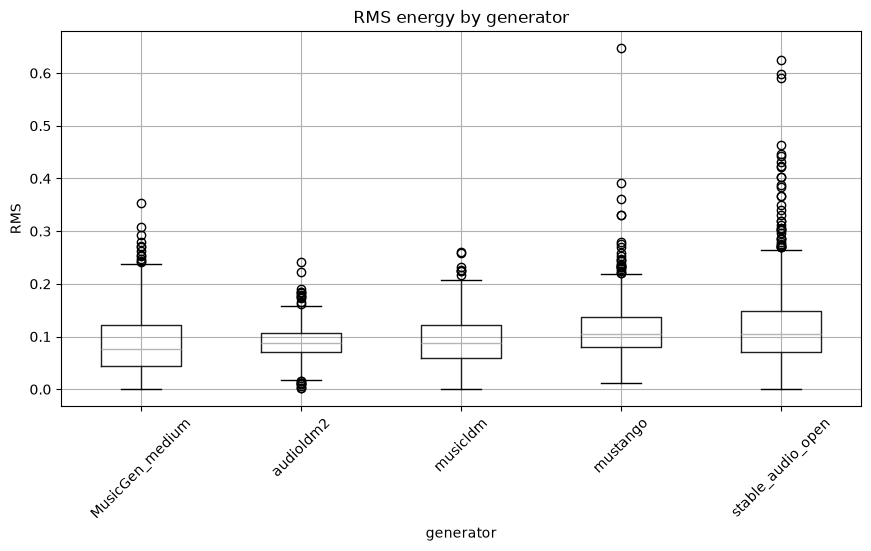

In [30]:
import matplotlib.pyplot as plt

handcrafted_df.boxplot(
    column="rms_mean",
    by="generator",
    figsize=(10, 5),
)

plt.title("RMS energy by generator")
plt.suptitle("")
plt.ylabel("RMS")
plt.xticks(rotation=45)
plt.show()

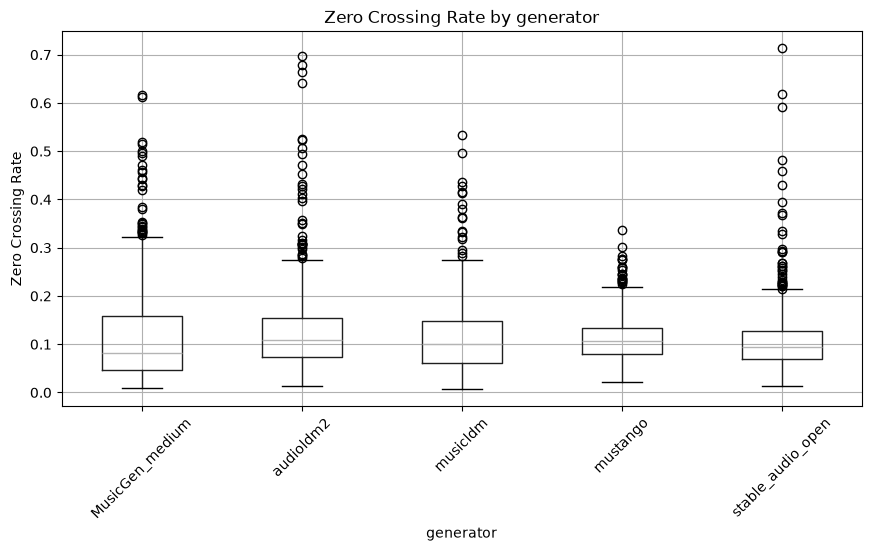

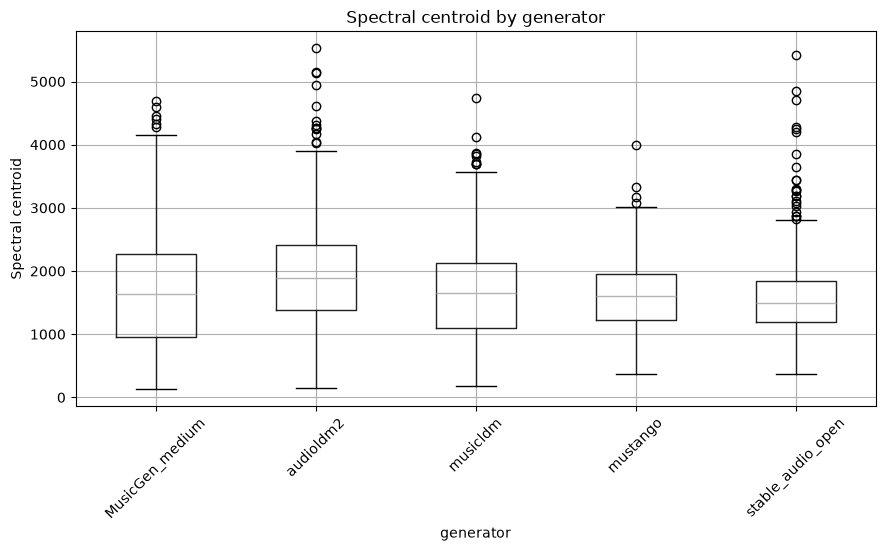

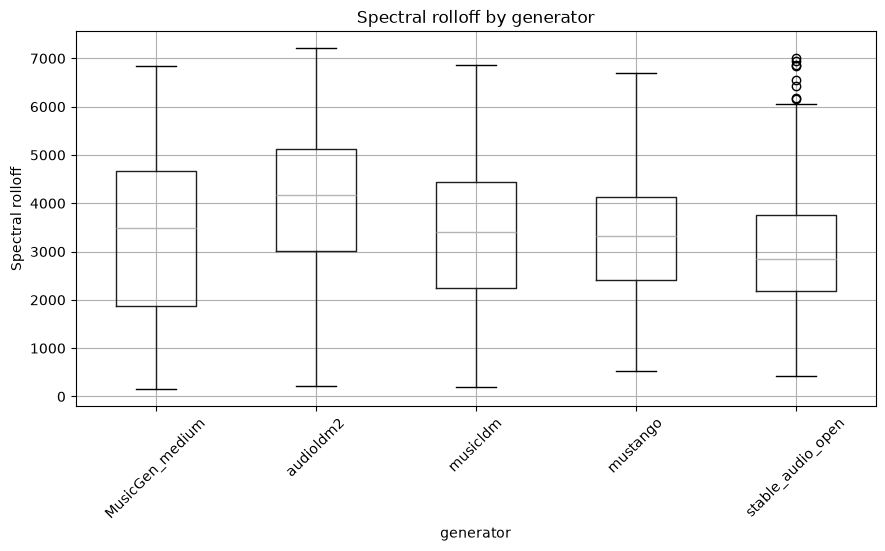

In [31]:
features_to_plot = [
    ("zero_mean", "Zero Crossing Rate by generator", "Zero Crossing Rate"),
    ("spectral_centroid_mean", "Spectral centroid by generator", "Spectral centroid"),
    ("spectral_rolloff_mean", "Spectral rolloff by generator", "Spectral rolloff"),
]

for feature, title, ylabel in features_to_plot:
    handcrafted_df.boxplot(
        column=feature,
        by="generator",
        figsize=(10, 5),
    )

    plt.title(title)
    plt.suptitle("")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.show()

### Feature distribution observations

The handcrafted features show some differences between generators.

- Stable Audio Open has the highest RMS values on average, while Mustango also tends to have higher energy than the other generators.
- Zero Crossing Rate differs only slightly between generators, and the distributions overlap strongly.
- AudioLDM2 shows higher spectral centroid and spectral rolloff values, while Stable Audio Open and Mustango generally have lower values.
- The distributions still overlap, so no single feature is enough to clearly separate all generators.

These results suggest that a combination of several handcrafted features may be more useful for generator classification than using individual features separately.

### MFCC analysis

MFCCs are features that describe the overall shape of the audio spectrum.

Each MFCC captures a different part of the sound, so one MFCC value is usually not very useful on its own. Together, they can help describe differences in the sound of music produced by different generators.

Here, we compare the first few MFCC mean values between generators to see if there are any visible differences.

In [32]:
handcrafted_df.groupby("generator")[
    ["mfcc_1_mean", "mfcc_2_mean", "mfcc_3_mean"]
].mean()

,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean
generator,,,
MusicGen_medium,-272.791399,80.956015,12.564992
audioldm2,-161.390873,75.181187,5.537546
musicldm,-196.127633,95.685119,-3.423866
mustango,-151.486870,102.486314,-8.962801
stable_audio_open,-252.192611,78.224825,-10.065951


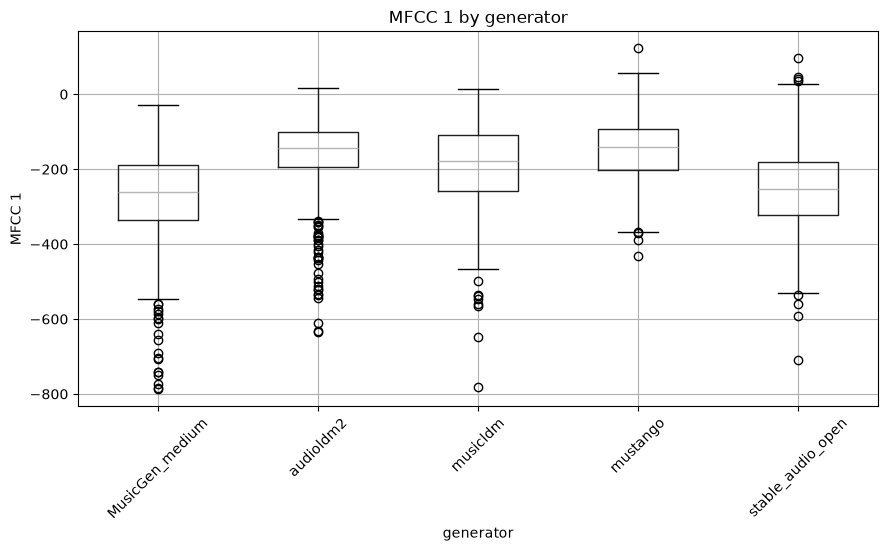

In [33]:
handcrafted_df.boxplot(
    column="mfcc_1_mean",
    by="generator",
    figsize=(10, 5),
)

plt.title("MFCC 1 by generator")
plt.suptitle("")
plt.ylabel("MFCC 1")
plt.xticks(rotation=45)
plt.show()

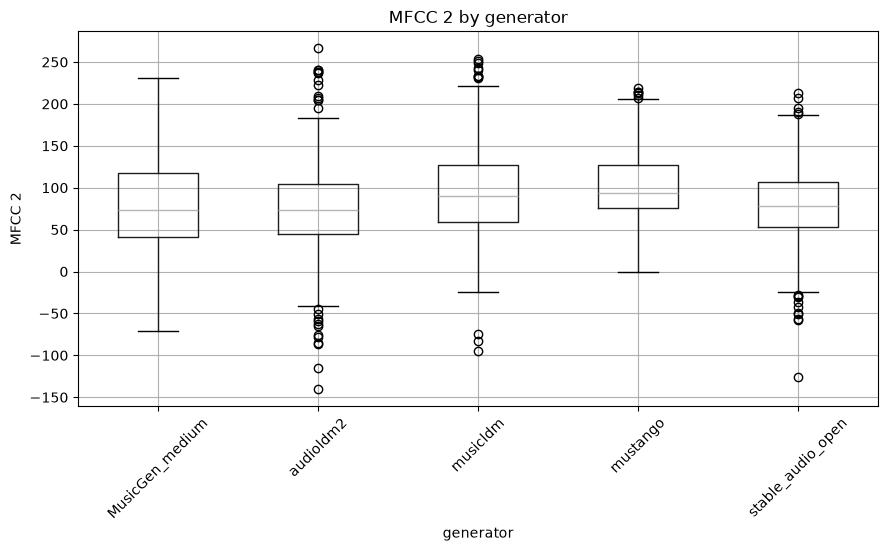

In [34]:
handcrafted_df.boxplot(
    column="mfcc_2_mean",
    by="generator",
    figsize=(10, 5),
)

plt.title("MFCC 2 by generator")
plt.suptitle("")
plt.ylabel("MFCC 2")
plt.xticks(rotation=45)
plt.show()

### MFCC observations

The MFCC distributions are different across generators, especially for MFCC 1.

MusicGen Medium and Stable Audio Open have lower MFCC 1 values, while AudioLDM2 and Mustango have higher values on average. MFCC 2 also shows some differences, but the distributions overlap more strongly.

Overall, MFCCs seem to contain useful information about generator-specific sound characteristics. However, no single MFCC clearly separates all generators, so they are more useful when combined with the other handcrafted features.

## Conclusions

The handcrafted feature analysis shows that several acoustic properties differ between music generators.

RMS, spectral centroid, spectral rolloff, and some MFCC coefficients show noticeable differences between classes. At the same time, the distributions still overlap, which means that individual features are not enough to clearly identify the generator.

This suggests that the full set of handcrafted features may be useful for classification when used together. These features can now be used in the next classification experiments.